In [37]:
# ── Jupyter plotting ──────────────────────────────────────────────────────────
%matplotlib inline

# ── Core libraries ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import scipy.stats as stats

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# ── Survival analysis libraries ───────────────────────────────────────────────

# lifelines — statistical survival models (KM, Nelson-Aalen, Cox PH, Weibull)
from lifelines import (
    KaplanMeierFitter,
    NelsonAalenFitter,
    CoxPHFitter,
    WeibullAFTFitter
)
from lifelines.statistics import logrank_test

# scikit-survival — ML-based survival models (Random Survival Forest, GBM)
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.preprocessing import OneHotEncoder as SurvivalEncoder
from sksurv.metrics import concordance_index_censored

# ── Color palette ─────────────────────────────────────────────────────────────
BLUE   = '#2563EB'
RED    = '#DC2626'
GREEN  = '#16A34A'
ORANGE = '#D97706'
PURPLE = '#7C3AED'
GRAY   = '#6B7280'

In [38]:
# ═══════════════════════════════════════════════════════════════════════════════
# LOAD DATA
# ═══════════════════════════════════════════════════════════════════════════════

df = pd.read_csv(
    r'C:\Users\marco\STA 6903 (Survival Analysis)\Data Analysis Project\GBSG2.csv'
)

print(df.head())
print(df.shape)

# ── Clean categorical variables ───────────────────────────────────────────────
df['horTh']    = df['horTh'].str.strip()
df['menostat'] = df['menostat'].str.strip()
df['tgrade']   = df['tgrade'].str.strip()

# ── Feature engineering ───────────────────────────────────────────────────────
df['horTh_bin']    = (df['horTh'] == 'yes').astype(int)
df['menostat_bin'] = (df['menostat'] == 'Post').astype(int)

df['tgrade_II']  = (df['tgrade'] == 'II').astype(int)
df['tgrade_III'] = (df['tgrade'] == 'III').astype(int)

df['log_progrec'] = np.log1p(df['progrec'])
df['log_estrec']  = np.log1p(df['estrec'])

# ── Survival variables ────────────────────────────────────────────────────────
T = df['time'].values.astype(float)
E = df['cens'].values.astype(float)

  horTh  age menostat  tsize tgrade  pnodes  progrec  estrec  time  cens
0    no   70     Post     21     II       3       48      66  1814     1
1   yes   56     Post     12     II       7       61      77  2018     1
2   yes   58     Post     35     II       9       52     271   712     1
3   yes   59     Post     17     II       4       60      29  1807     1
4    no   73     Post     35     II       1       26      65   772     1
(686, 10)


In [39]:
# ═══════════════════════════════════════════════════════════════════════════════
# DESCRIPTIVE STATISTICS
# ═══════════════════════════════════════════════════════════════════════════════

print("===== DESCRIPTIVE STATISTICS =====")
print(df.describe())

print("\nHormone Therapy Counts")
print(df['horTh'].value_counts())

print("\nMenopausal Status Counts")
print(df['menostat'].value_counts())

print("\nTumor Grade Counts")
print(df['tgrade'].value_counts())

===== DESCRIPTIVE STATISTICS =====
              age       tsize      pnodes      progrec       estrec  \
count  686.000000  686.000000  686.000000   686.000000   686.000000   
mean    53.052478   29.329446    5.010204   109.995627    96.252187   
std     10.120739   14.296217    5.475483   202.331552   153.083963   
min     21.000000    3.000000    1.000000     0.000000     0.000000   
25%     46.000000   20.000000    1.000000     7.000000     8.000000   
50%     53.000000   25.000000    3.000000    32.500000    36.000000   
75%     61.000000   35.000000    7.000000   131.750000   114.000000   
max     80.000000  120.000000   51.000000  2380.000000  1144.000000   

              time        cens   horTh_bin  menostat_bin  tgrade_II  \
count   686.000000  686.000000  686.000000    686.000000  686.00000   
mean   1124.489796    0.435860    0.358601      0.577259    0.64723   
std     642.791948    0.496231    0.479940      0.494355    0.47818   
min       8.000000    0.000000    0.00000

In [40]:
# ═══════════════════════════════════════════════════════════════════════════════
# KAPLAN-MEIER FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════════

def kaplan_meier(time, event):

    df_km = pd.DataFrame({
        'time': time,
        'event': event
    }).sort_values('time').reset_index(drop=True)

    unique_times = np.sort(
        df_km[df_km['event'] == 1]['time'].unique()
    )

    S      = 1.0
    log_var = 0.0

    survival = []
    ci_lower = []
    ci_upper = []
    times_out = []

    for t in unique_times:

        d = int(
            ((df_km['time'] == t) &
             (df_km['event'] == 1)).sum()
        )

        at_risk = int(
            (df_km['time'] >= t).sum()
        )

        S *= (1 - d / at_risk)

        if at_risk - d > 0:
            log_var += d / (at_risk * (at_risk - d))

        if 0 < S < 1:
            log_log_S = np.log(-np.log(S))
            se_ll     = np.sqrt(log_var) / abs(np.log(S))
            ll = np.exp(-np.exp(log_log_S + 1.96 * se_ll))
            ul = np.exp(-np.exp(log_log_S - 1.96 * se_ll))
        else:
            ll = ul = S

        survival.append(S)
        ci_lower.append(ll)
        ci_upper.append(ul)
        times_out.append(t)

    return (
        np.array(times_out),
        np.array(survival),
        np.array(ci_lower),
        np.array(ci_upper)
    )


def km_step(ax, times, surv, lo, hi, color, label):

    t_plot = np.concatenate([[0], times])
    s_plot = np.concatenate([[1], surv])
    l_plot = np.concatenate([[1], lo])
    u_plot = np.concatenate([[1], hi])

    ax.step(t_plot, s_plot, where='post', color=color, linewidth=2, label=label)
    ax.fill_between(t_plot, l_plot, u_plot, step='post', alpha=0.12, color=color)

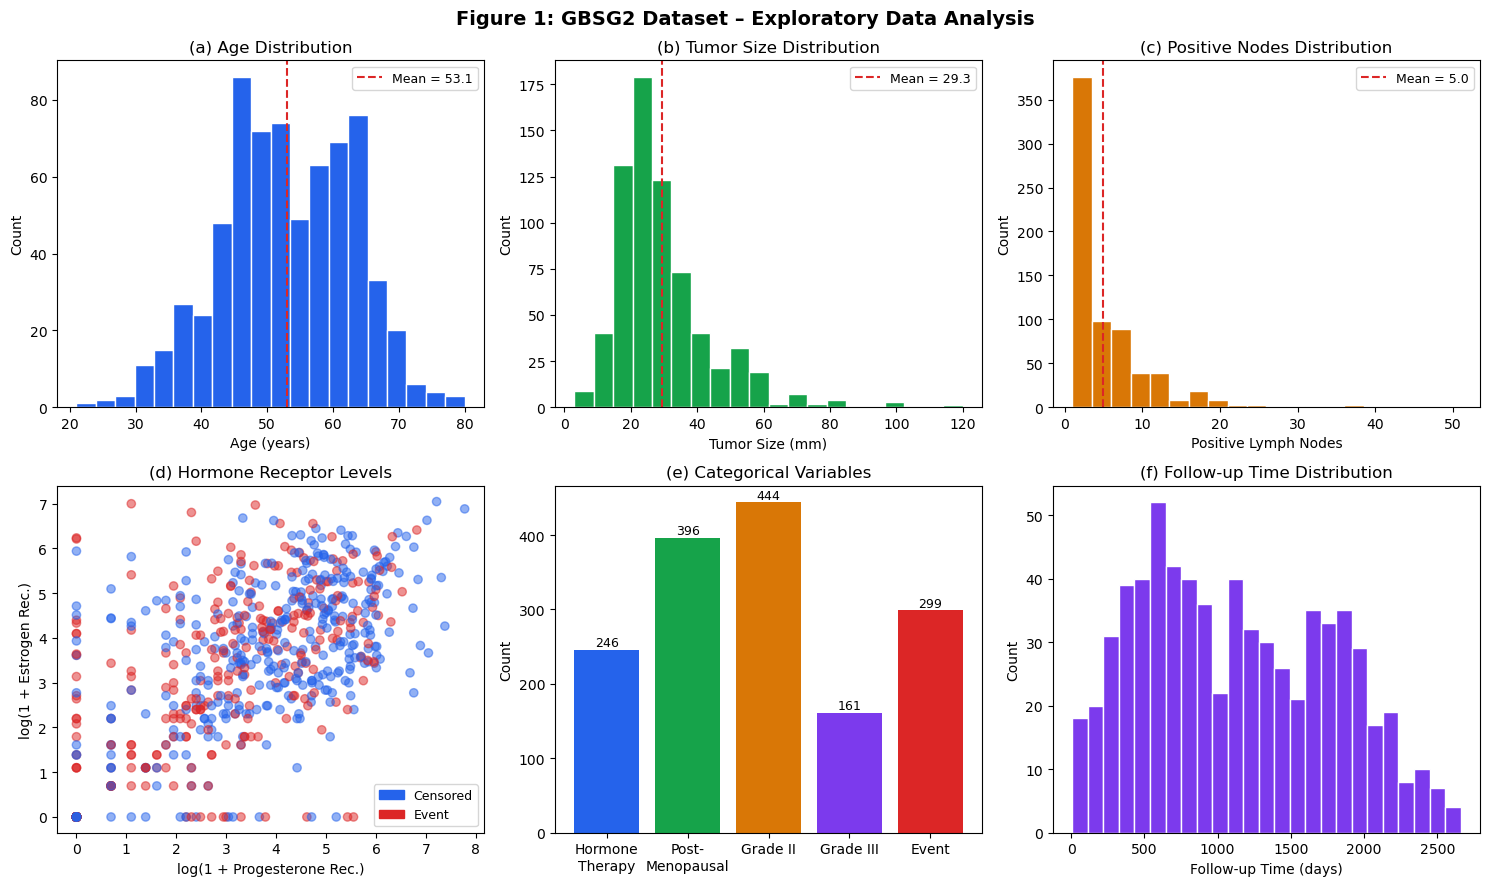

In [41]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — EXPLORATORY DATA ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

fig.suptitle(
    'Figure 1: GBSG2 Dataset – Exploratory Data Analysis',
    fontsize=14,
    fontweight='bold'
)

# ── (a) Age ───────────────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.hist(df['age'], bins=20, color=BLUE, edgecolor='white')
ax.axvline(df['age'].mean(), color=RED, linestyle='--', linewidth=1.5,
           label=f'Mean = {df["age"].mean():.1f}')
ax.set_title('(a) Age Distribution')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

# ── (b) Tumor size ────────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.hist(df['tsize'], bins=20, color=GREEN, edgecolor='white')
ax.axvline(df['tsize'].mean(), color=RED, linestyle='--', linewidth=1.5,
           label=f'Mean = {df["tsize"].mean():.1f}')
ax.set_title('(b) Tumor Size Distribution')
ax.set_xlabel('Tumor Size (mm)')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

# ── (c) Positive nodes ────────────────────────────────────────────────────────
ax = axes[0, 2]
ax.hist(df['pnodes'], bins=20, color=ORANGE, edgecolor='white')
ax.axvline(df['pnodes'].mean(), color=RED, linestyle='--', linewidth=1.5,
           label=f'Mean = {df["pnodes"].mean():.1f}')
ax.set_title('(c) Positive Nodes Distribution')
ax.set_xlabel('Positive Lymph Nodes')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

# ── (d) Hormone receptor scatter ──────────────────────────────────────────────
ax = axes[1, 0]
color_map = df['cens'].map({0: BLUE, 1: RED})
ax.scatter(df['log_progrec'], df['log_estrec'], c=color_map, alpha=0.5)
censored_patch = mpatches.Patch(color=BLUE, label='Censored')
event_patch    = mpatches.Patch(color=RED,  label='Event')
ax.legend(handles=[censored_patch, event_patch], fontsize=9)
ax.set_title('(d) Hormone Receptor Levels')
ax.set_xlabel('log(1 + Progesterone Rec.)')
ax.set_ylabel('log(1 + Estrogen Rec.)')

# ── (e) Categorical counts ────────────────────────────────────────────────────
ax = axes[1, 1]
cats = {
    'Hormone\nTherapy': df['horTh_bin'].sum(),
    'Post-\nMenopausal': df['menostat_bin'].sum(),
    'Grade II': df['tgrade_II'].sum(),
    'Grade III': df['tgrade_III'].sum(),
    'Event': int(E.sum())
}
ax.bar(cats.keys(), cats.values(), color=[BLUE, GREEN, ORANGE, PURPLE, RED])
for i, (k, v) in enumerate(cats.items()):
    ax.text(i, v + 5, str(v), ha='center', fontsize=9)
ax.set_title('(e) Categorical Variables')
ax.set_ylabel('Count')

# ── (f) Follow-up time ────────────────────────────────────────────────────────
ax = axes[1, 2]
ax.hist(df['time'], bins=25, color=PURPLE, edgecolor='white')
ax.set_title('(f) Follow-up Time Distribution')
ax.set_xlabel('Follow-up Time (days)')
ax.set_ylabel('Count')

plt.tight_layout()

plt.savefig(
    r'C:\Users\marco\STA 6903 (Survival Analysis)\Data Analysis Project\fig1_eda.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

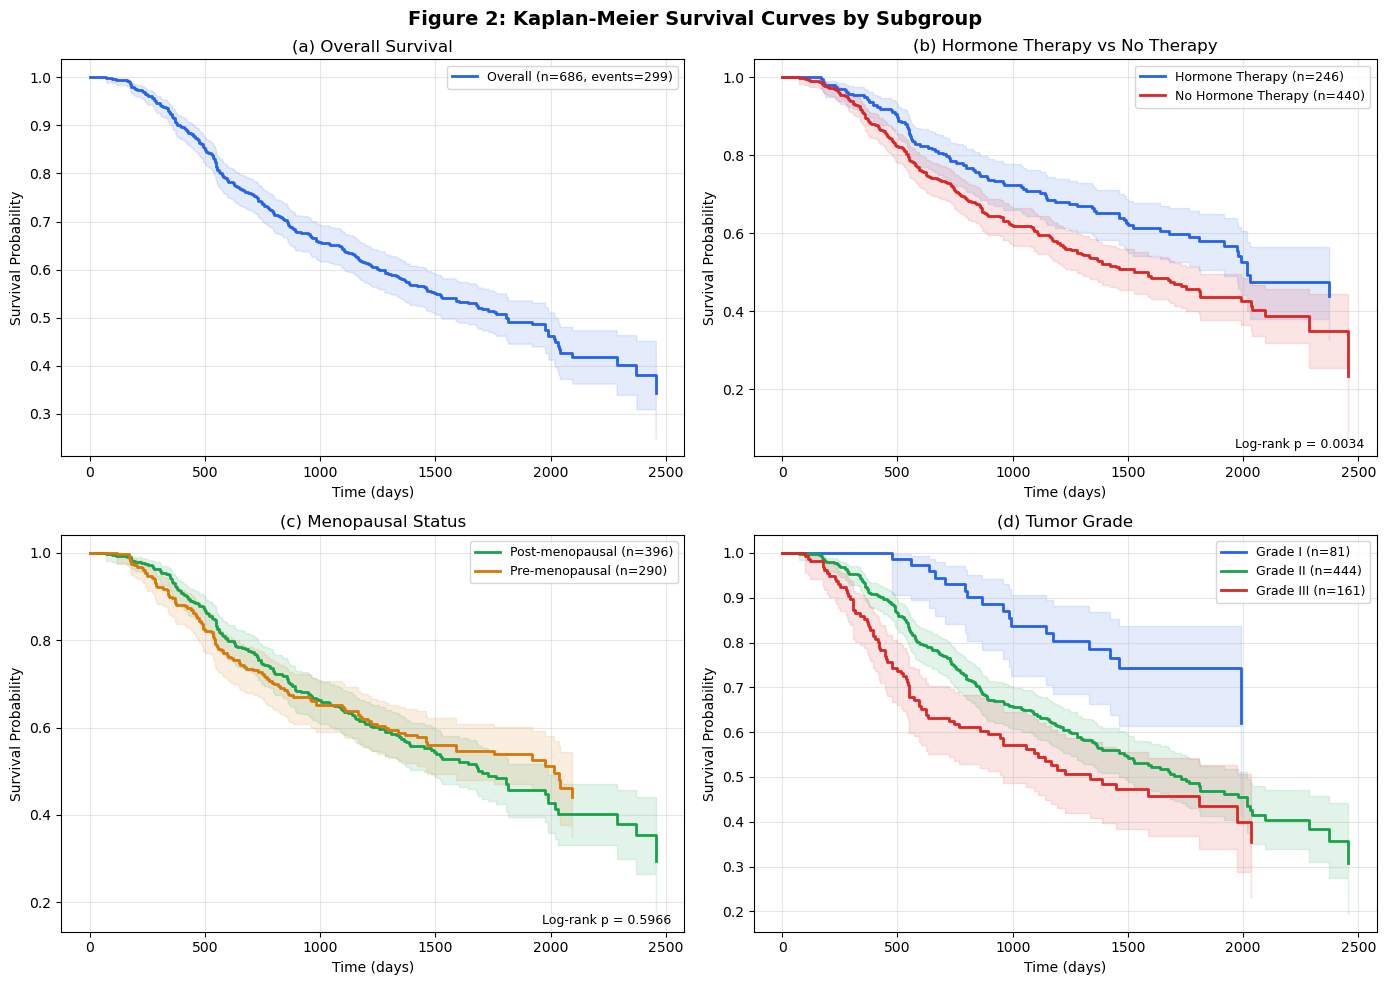

In [42]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — KAPLAN-MEIER SURVIVAL CURVES
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fig.suptitle(
    'Figure 2: Kaplan-Meier Survival Curves by Subgroup',
    fontsize=14,
    fontweight='bold'
)

# ── (a) Overall survival ──────────────────────────────────────────────────────
ax = axes[0, 0]
t_all, s_all, lo_all, hi_all = kaplan_meier(T, E)
km_step(ax, t_all, s_all, lo_all, hi_all, BLUE, f'Overall (n={len(T)}, events={int(E.sum())})')
ax.set_title('(a) Overall Survival')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Survival Probability')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── (b) Hormone therapy ───────────────────────────────────────────────────────
ax = axes[0, 1]
for grp, color, label in [
    ('yes', BLUE, f'Hormone Therapy (n={int((df["horTh"]=="yes").sum())})'),
    ('no',  RED,  f'No Hormone Therapy (n={int((df["horTh"]=="no").sum())})')
]:
    mask = df['horTh'] == grp
    tg, sg, lg, hg = kaplan_meier(T[mask], E[mask])
    km_step(ax, tg, sg, lg, hg, color, label)
ax.set_title('(b) Hormone Therapy vs No Therapy')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Survival Probability')
ax.legend(fontsize=9)
ax.text(0.98, 0.02, 'Log-rank p = 0.0034', transform=ax.transAxes,
        ha='right', fontsize=9, color='black')
ax.grid(alpha=0.3)

# ── (c) Menopausal status ─────────────────────────────────────────────────────
ax = axes[1, 0]
for grp, color, label in [
    ('Post', GREEN,  f'Post-menopausal (n={int((df["menostat"]=="Post").sum())})'),
    ('Pre',  ORANGE, f'Pre-menopausal (n={int((df["menostat"]=="Pre").sum())})')
]:
    mask = df['menostat'] == grp
    tg, sg, lg, hg = kaplan_meier(T[mask], E[mask])
    km_step(ax, tg, sg, lg, hg, color, label)
ax.set_title('(c) Menopausal Status')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Survival Probability')
ax.legend(fontsize=9)
ax.text(0.98, 0.02, 'Log-rank p = 0.5966', transform=ax.transAxes,
        ha='right', fontsize=9, color='black')
ax.grid(alpha=0.3)

# ── (d) Tumor grade ───────────────────────────────────────────────────────────
ax = axes[1, 1]
for grade, color in zip(['I', 'II', 'III'], [BLUE, GREEN, RED]):
    mask = df['tgrade'] == grade
    tg, sg, lg, hg = kaplan_meier(T[mask], E[mask])
    km_step(ax, tg, sg, lg, hg, color, f'Grade {grade} (n={int(mask.sum())})')
ax.set_title('(d) Tumor Grade')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Survival Probability')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    r'C:\Users\marco\STA 6903 (Survival Analysis)\Data Analysis Project\fig2_km.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [43]:
# ═══════════════════════════════════════════════════════════════════════════════
# COX PROPORTIONAL HAZARDS MODEL — FIT
# ═══════════════════════════════════════════════════════════════════════════════

covariates = [
    'horTh_bin', 'age', 'menostat_bin', 'tsize',
    'tgrade_II', 'tgrade_III', 'pnodes', 'log_progrec', 'log_estrec'
]

X = df[covariates].values.astype(float)


def neg_log_pl(beta):
    xb    = X @ beta
    order = np.argsort(T)[::-1]
    xb_s  = xb[order]
    E_s   = E[order]
    offset  = xb_s.max()
    exp_xb  = np.exp(xb_s - offset)
    log_cum = np.log(np.cumsum(exp_xb)) + offset
    return -np.sum((xb_s - log_cum)[E_s == 1])


def neg_grad(beta):
    xb    = X @ beta
    order = np.argsort(T)[::-1]
    E_s   = E[order]
    xb_s  = xb[order]
    X_s   = X[order]
    exp_xb   = np.exp(xb_s - xb_s.max())
    cum_exp  = np.cumsum(exp_xb)
    cum_Xexp = np.cumsum(X_s * exp_xb[:, None], axis=0)
    Ebar     = cum_Xexp / cum_exp[:, None]
    return -np.sum((X_s - Ebar)[E_s == 1], axis=0)


beta0  = np.zeros(len(covariates))
result = minimize(neg_log_pl, beta0, jac=neg_grad, method='L-BFGS-B')
betas  = result.x

print("===== COX MODEL COEFFICIENTS =====")
for name, beta in zip(covariates, betas):
    print(f"  {name}: {beta:.4f}")

===== COX MODEL COEFFICIENTS =====
  horTh_bin: -0.3500
  age: -0.0096
  menostat_bin: 0.2268
  tsize: 0.0062
  tgrade_II: 0.5316
  tgrade_III: 0.5886
  pnodes: 0.0516
  log_progrec: -0.1958
  log_estrec: 0.0298


In [44]:
# ═══════════════════════════════════════════════════════════════════════════════
# COX PROPORTIONAL HAZARDS MODEL — STANDARD ERRORS & RESULTS TABLE
# ═══════════════════════════════════════════════════════════════════════════════

h = 1e-4
n = len(betas)
H = np.zeros((n, n))

for i in range(n):
    ei    = np.zeros(n)
    ei[i] = h
    H[i]  = (neg_grad(betas + ei) - neg_grad(betas - ei)) / (2 * h)

H   = (H + H.T) / 2
cov = np.linalg.pinv(H)
se  = np.sqrt(np.diag(cov))

cox_results = []
for name, b, s in zip(covariates, betas, se):
    hr = np.exp(b)
    lo = np.exp(b - 1.96 * s)
    hi = np.exp(b + 1.96 * s)
    z  = b / s
    p  = 2 * (1 - stats.norm.cdf(abs(z)))
    cox_results.append({'Variable': name, 'Coef': b, 'SE': s,
                        'HR': hr, 'Lower CI': lo, 'Upper CI': hi, 'p-value': p})

cox_df = pd.DataFrame(cox_results)
print("===== COX RESULTS =====")
print(cox_df.to_string(index=False))

cox_df.to_csv(
    r'C:\Users\marco\STA 6903 (Survival Analysis)\Data Analysis Project\cox_results.csv',
    index=False
)

===== COX RESULTS =====
    Variable      Coef       SE       HR  Lower CI  Upper CI      p-value
   horTh_bin -0.350028 0.129107 0.704668  0.547125  0.907576 6.705260e-03
         age -0.009604 0.009114 0.990442  0.972907  1.008294 2.920122e-01
menostat_bin  0.226753 0.183673 1.254520  0.875250  1.798137 2.169981e-01
       tsize  0.006207 0.003976 1.006226  0.998415  1.014099 1.185313e-01
   tgrade_II  0.531552 0.251749 1.701571  1.038861  2.787037 3.473451e-02
  tgrade_III  0.588576 0.276061 1.801421  1.048643  3.094589 3.300249e-02
      pnodes  0.051594 0.007677 1.052948  1.037224  1.068910 1.804712e-11
 log_progrec -0.195799 0.040817 0.822177  0.758965  0.890654 1.610214e-06
  log_estrec  0.029780 0.042039 1.030228  0.948744  1.118710 4.786984e-01


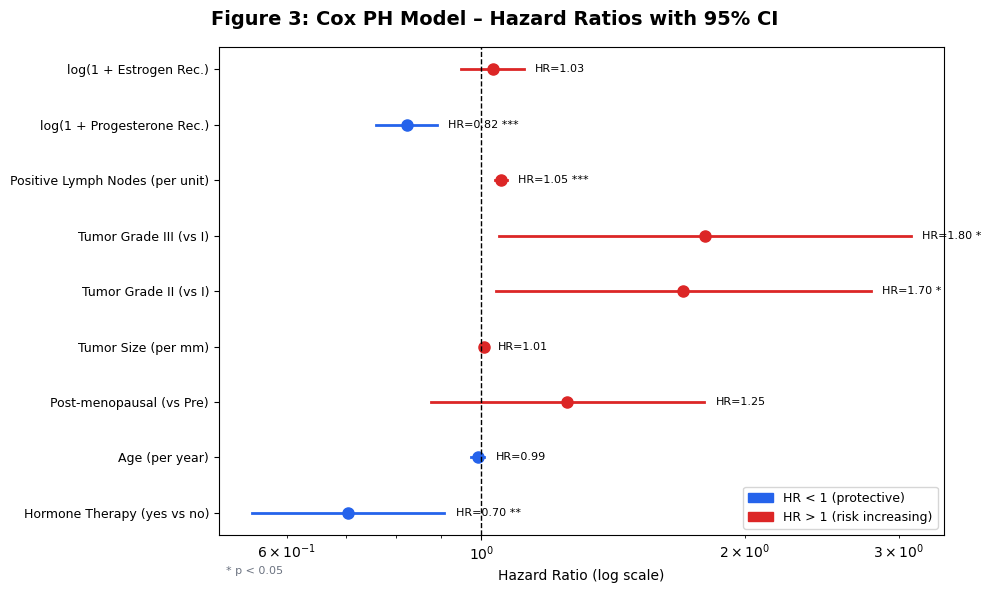

In [45]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — FOREST PLOT (COX PH HAZARD RATIOS)
# ═══════════════════════════════════════════════════════════════════════════════

labels_pretty = [
    'Hormone Therapy (yes vs no)', 'Age (per year)', 'Post-menopausal (vs Pre)',
    'Tumor Size (per mm)', 'Tumor Grade II (vs I)', 'Tumor Grade III (vs I)',
    'Positive Lymph Nodes (per unit)', 'log(1 + Progesterone Rec.)', 'log(1 + Estrogen Rec.)'
]

fig, ax = plt.subplots(figsize=(10, 6))

fig.suptitle(
    'Figure 3: Cox PH Model – Hazard Ratios with 95% CI',
    fontsize=14,
    fontweight='bold'
)

y_pos = np.arange(len(cox_df))

for i, row in cox_df.iterrows():
    color = RED if row['HR'] > 1 else BLUE
    ax.plot([row['Lower CI'], row['Upper CI']], [i, i], color=color, linewidth=2)
    ax.plot(row['HR'], i, 'o', color=color, markersize=8)

    sig = ''
    if row['p-value'] < 0.001:
        sig = ' ***'
    elif row['p-value'] < 0.01:
        sig = ' **'
    elif row['p-value'] < 0.05:
        sig = ' *'

    ax.text(row['Upper CI'] * 1.03, i,
            f"HR={row['HR']:.2f}{sig}", va='center', fontsize=8)

ax.axvline(1, color='black', linestyle='--', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels_pretty, fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('Hazard Ratio (log scale)')

blue_patch = mpatches.Patch(color=BLUE, label='HR < 1 (protective)')
red_patch  = mpatches.Patch(color=RED,  label='HR > 1 (risk increasing)')
ax.legend(handles=[blue_patch, red_patch], fontsize=9, loc='lower right')

ax.text(0.01, -0.08, '* p < 0.05', transform=ax.transAxes, fontsize=8, color=GRAY)

plt.tight_layout()

plt.savefig(
    r'C:\Users\marco\STA 6903 (Survival Analysis)\Data Analysis Project\fig3_forest.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

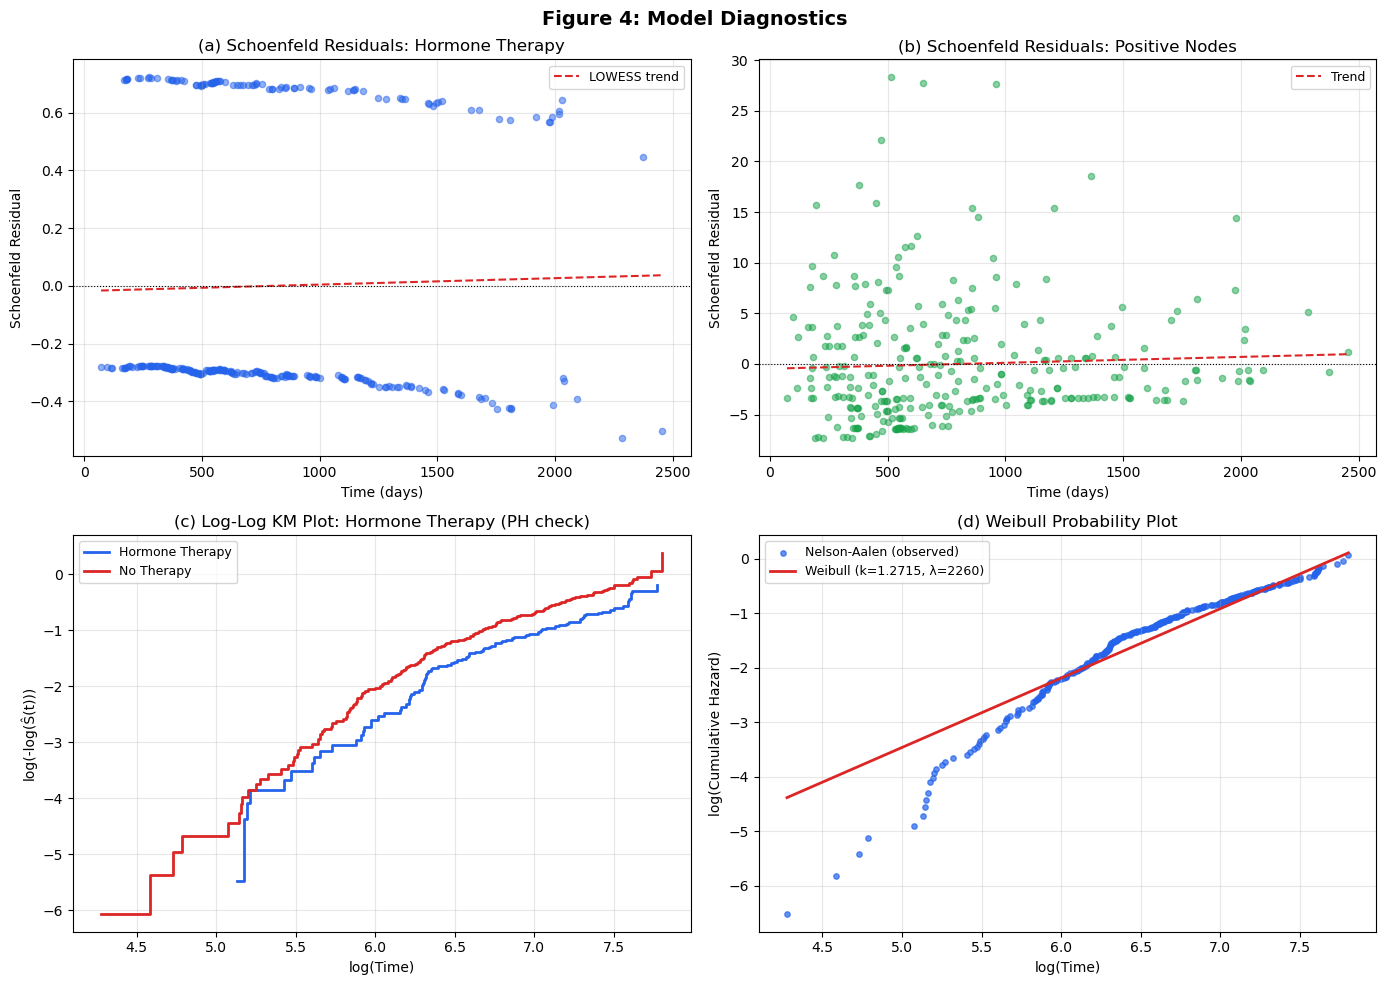

Figure 4 saved.


In [46]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — MODEL DIAGNOSTICS
# ═══════════════════════════════════════════════════════════════════════════════

# ── Schoenfeld residuals (manual) ─────────────────────────────────────────────
# At each event time, the Schoenfeld residual for covariate j is:
#   r_j(t) = x_j(i) - E[x_j | risk set at t]
# where i is the subject who failed at time t.

def schoenfeld_residuals(T, E, X, betas):
    """
    Returns event times and Schoenfeld residuals (one column per covariate).
    """
    order  = np.argsort(T)
    T_s    = T[order]
    E_s    = E[order]
    X_s    = X[order]

    exp_xb = np.exp(X_s @ betas)

    event_times = []
    residuals   = []

    for i in range(len(T_s)):
        if E_s[i] == 1:
            risk_exp    = exp_xb[i:]          # risk set starts at i (descending sort reversed)
            risk_X      = X_s[i:]

            w           = risk_exp / risk_exp.sum()
            E_x         = (risk_X * w[:, None]).sum(axis=0)

            residuals.append(X_s[i] - E_x)
            event_times.append(T_s[i])

    return np.array(event_times), np.array(residuals)


event_t, sch_resid = schoenfeld_residuals(T, E, X, betas)

# ── Baseline cumulative hazard (Breslow) ──────────────────────────────────────

def breslow_baseline(T, E, X, betas):
    """Returns sorted unique event times and cumulative baseline hazard H0."""
    xb     = X @ betas
    order  = np.argsort(T)
    T_s    = T[order]
    E_s    = E[order]
    xb_s   = xb[order]

    unique_evt = np.sort(np.unique(T_s[E_s == 1]))
    H0         = []
    cumH       = 0.0

    for t in unique_evt:
        d        = int(((T_s == t) & (E_s == 1)).sum())
        risk_exp = np.exp(xb_s[T_s >= t]).sum()
        cumH    += d / risk_exp
        H0.append(cumH)

    return unique_evt, np.array(H0)

evt_times_bl, H0 = breslow_baseline(T, E, X, betas)

# ── Nelson-Aalen estimator ────────────────────────────────────────────────────

def nelson_aalen(T, E):
    order  = np.argsort(T)
    T_s    = T[order]
    E_s    = E[order]

    unique_evt = np.sort(np.unique(T_s[E_s == 1]))
    H          = []
    cumH       = 0.0

    for t in unique_evt:
        d     = int(((T_s == t) & (E_s == 1)).sum())
        n_t   = int((T_s >= t).sum())
        cumH += d / n_t
        H.append(cumH)

    return unique_evt, np.array(H)

na_times, na_H = nelson_aalen(T, E)

# ── Covariate indices for Schoenfeld panels ───────────────────────────────────
cov_labels = [
    'horTh_bin', 'age', 'menostat_bin', 'tsize',
    'tgrade_II', 'tgrade_III', 'pnodes', 'log_progrec', 'log_estrec'
]

idx_hor   = cov_labels.index('horTh_bin')
idx_nodes = cov_labels.index('pnodes')

# ── Build the 2×2 figure ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fig.suptitle(
    'Figure 4: Model Diagnostics',
    fontsize=14,
    fontweight='bold'
)

# ── Panel (a): Schoenfeld residuals — Hormone Therapy ────────────────────────
ax = axes[0, 0]

ax.scatter(
    event_t,
    sch_resid[:, idx_hor],
    alpha=0.5,
    s=20,
    color=BLUE
)

z = np.polyfit(event_t, sch_resid[:, idx_hor], 1)
p_fit = np.poly1d(z)
t_line = np.linspace(event_t.min(), event_t.max(), 300)

ax.plot(
    t_line,
    p_fit(t_line),
    color=RED,
    linestyle='--',
    linewidth=1.5,
    label='LOWESS trend'
)

ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.set_title('(a) Schoenfeld Residuals: Hormone Therapy')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Schoenfeld Residual')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── Panel (b): Schoenfeld residuals — Positive Nodes ─────────────────────────
ax = axes[0, 1]

ax.scatter(
    event_t,
    sch_resid[:, idx_nodes],
    alpha=0.5,
    s=20,
    color=GREEN
)

z2 = np.polyfit(event_t, sch_resid[:, idx_nodes], 1)
p_fit2 = np.poly1d(z2)

ax.plot(
    t_line,
    p_fit2(t_line),
    color=RED,
    linestyle='--',
    linewidth=1.5,
    label='Trend'
)

ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.set_title('(b) Schoenfeld Residuals: Positive Nodes')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Schoenfeld Residual')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── Panel (c): Log-log KM plot for Hormone Therapy ───────────────────────────
ax = axes[1, 0]

for grp, color, label in [
    ('yes', BLUE,  'Hormone Therapy'),
    ('no',  RED,   'No Therapy')
]:
    mask    = df['horTh'] == grp
    tg, sg, _, _ = kaplan_meier(T[mask], E[mask])

    # Keep only interior points where 0 < S < 1
    valid = (sg > 0) & (sg < 1)
    log_t  = np.log(tg[valid])
    log_ls = np.log(-np.log(sg[valid]))

    ax.step(log_t, log_ls, where='post', color=color, linewidth=2, label=label)

ax.set_title('(c) Log-Log KM Plot: Hormone Therapy (PH check)')
ax.set_xlabel('log(Time)')
ax.set_ylabel('log(-log(Ŝ(t)))')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── Panel (d): Weibull probability plot ──────────────────────────────────────
ax = axes[1, 1]

# Estimated Weibull parameters from MLE on marginal data
k_hat  = 1.2715
lam_hat = 2259.9

valid_na = na_H > 0
log_t_na  = np.log(na_times[valid_na])
log_H_na  = np.log(na_H[valid_na])

ax.scatter(log_t_na, log_H_na, s=15, alpha=0.7, color=BLUE, label='Nelson-Aalen (observed)')

# Weibull theoretical line: log H(t) = k*log(t) - k*log(lambda)
t_range  = np.linspace(na_times[valid_na].min(), na_times[valid_na].max(), 300)
weibull_logH = k_hat * np.log(t_range) - k_hat * np.log(lam_hat)

ax.plot(
    np.log(t_range),
    weibull_logH,
    color=RED,
    linewidth=2,
    label=f'Weibull (k={k_hat}, λ={lam_hat:.0f})'
)

ax.set_title('(d) Weibull Probability Plot')
ax.set_xlabel('log(Time)')
ax.set_ylabel('log(Cumulative Hazard)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    r'C:\Users\marco\STA 6903 (Survival Analysis)\Data Analysis Project\fig4_forest.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure 4 saved.")


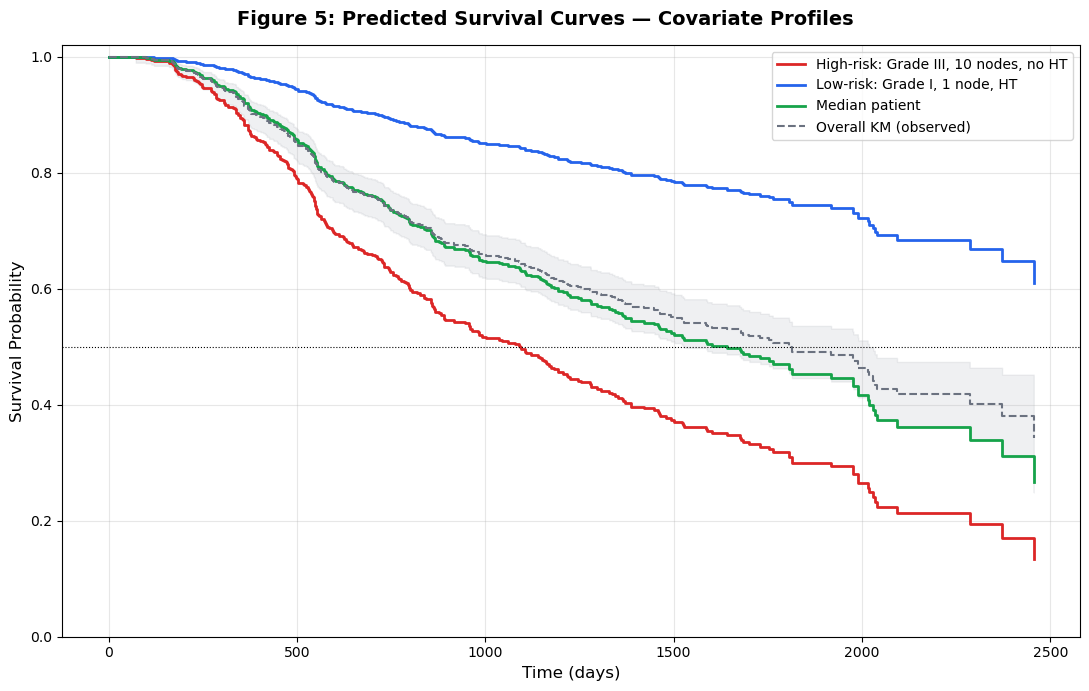

Figure 5 saved.


In [47]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 5 — PREDICTED SURVIVAL CURVES (COX PH, THREE PROFILES)
# ═══════════════════════════════════════════════════════════════════════════════

# ── Predicted survival from Cox PH using Breslow baseline ────────────────────
# S(t | x) = S0(t)^exp(x @ beta)

def cox_survival_profile(xvec, evt_times_bl, H0, betas):
    """Return (times, S(t)) for a covariate vector xvec."""
    risk_score = float(np.exp(xvec @ betas))
    S          = np.exp(-H0 * risk_score)
    return evt_times_bl, S


# ── Define three profiles ─────────────────────────────────────────────────────
# Covariates order: horTh_bin, age, menostat_bin, tsize,
#                   tgrade_II, tgrade_III, pnodes, log_progrec, log_estrec

# Profile 1 — High-risk: Grade III, 10 nodes, no hormone therapy
x_high = np.array([0, 53, 1, 25, 0, 1, 10,
                   np.log1p(df['progrec'].median()),
                   np.log1p(df['estrec'].median())], dtype=float)

# Profile 2 — Low-risk: Grade I, 1 node, hormone therapy
x_low  = np.array([1, 53, 1, 25, 0, 0, 1,
                   np.log1p(df['progrec'].median()),
                   np.log1p(df['estrec'].median())], dtype=float)

# Profile 3 — Median patient (use column medians)
x_med  = np.array([
    df['horTh_bin'].median(),
    df['age'].median(),
    df['menostat_bin'].median(),
    df['tsize'].median(),
    df['tgrade_II'].median(),
    df['tgrade_III'].median(),
    df['pnodes'].median(),
    df['log_progrec'].median(),
    df['log_estrec'].median()
], dtype=float)


t_high, s_high = cox_survival_profile(x_high, evt_times_bl, H0, betas)
t_low,  s_low  = cox_survival_profile(x_low,  evt_times_bl, H0, betas)
t_med,  s_med  = cox_survival_profile(x_med,  evt_times_bl, H0, betas)

# ── Overall KM for reference ──────────────────────────────────────────────────
t_all, s_all, lo_all, hi_all = kaplan_meier(T, E)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

fig.suptitle(
    'Figure 5: Predicted Survival Curves — Covariate Profiles',
    fontsize=14,
    fontweight='bold'
)

ax.step(
    np.concatenate([[0], t_high]),
    np.concatenate([[1], s_high]),
    where='post',
    color=RED,
    linewidth=2,
    label='High-risk: Grade III, 10 nodes, no HT'
)

ax.step(
    np.concatenate([[0], t_low]),
    np.concatenate([[1], s_low]),
    where='post',
    color=BLUE,
    linewidth=2,
    label='Low-risk: Grade I, 1 node, HT'
)

ax.step(
    np.concatenate([[0], t_med]),
    np.concatenate([[1], s_med]),
    where='post',
    color=GREEN,
    linewidth=2,
    label='Median patient'
)

# Overall KM (gray, with CI)
t_plot = np.concatenate([[0], t_all])
s_plot = np.concatenate([[1], s_all])
l_plot = np.concatenate([[1], lo_all])
u_plot = np.concatenate([[1], hi_all])

ax.step(
    t_plot,
    s_plot,
    where='post',
    color=GRAY,
    linewidth=1.5,
    linestyle='--',
    label='Overall KM (observed)'
)

ax.fill_between(
    t_plot,
    l_plot,
    u_plot,
    step='post',
    alpha=0.10,
    color=GRAY
)

ax.axhline(0.5, color='black', linestyle=':', linewidth=0.8)

ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Survival Probability', fontsize=12)
ax.set_ylim(0, 1.02)
ax.legend(fontsize=10, loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
        r'C:\Users\marco\STA 6903 (Survival Analysis)\Data Analysis Project\fig5_predicted_survival.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure 5 saved.")


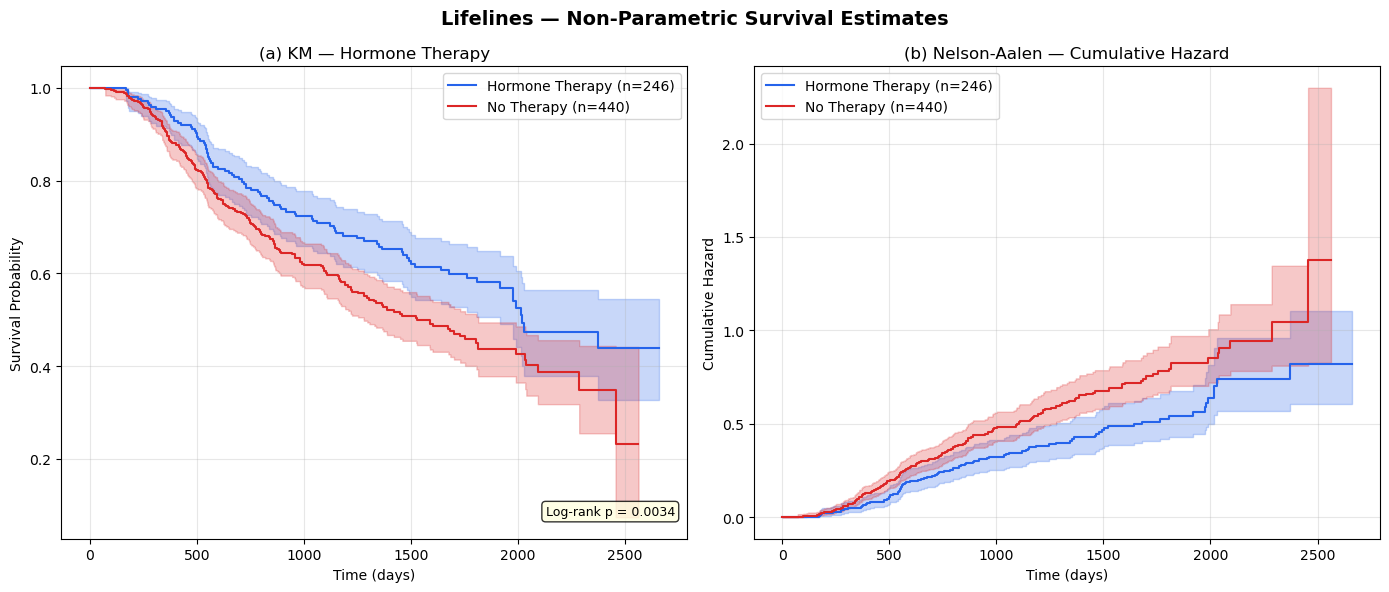

Log-rank test: statistic=8.5648, p=0.0034


In [48]:
# ═══════════════════════════════════════════════════════════════════════════════
# LIFELINES — KAPLAN-MEIER, NELSON-AALEN & LOG-RANK TEST
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Lifelines — Non-Parametric Survival Estimates', fontsize=14, fontweight='bold')

# ── (a) KM by hormone therapy ─────────────────────────────────────────────────
ax = axes[0]
mask_ht = df['horTh'] == 'yes'
mask_no = df['horTh'] == 'no'

kmf_ht = KaplanMeierFitter()
kmf_ht.fit(T[mask_ht], event_observed=E[mask_ht],
           label=f'Hormone Therapy (n={mask_ht.sum()})')
kmf_ht.plot_survival_function(ax=ax, ci_show=True, color=BLUE)

kmf_no = KaplanMeierFitter()
kmf_no.fit(T[mask_no], event_observed=E[mask_no],
           label=f'No Therapy (n={mask_no.sum()})')
kmf_no.plot_survival_function(ax=ax, ci_show=True, color=RED)

lr = logrank_test(T[mask_ht], T[mask_no], E[mask_ht], E[mask_no])
ax.text(0.98, 0.05, f'Log-rank p = {lr.p_value:.4f}',
        transform=ax.transAxes, ha='right', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
ax.set_title('(a) KM — Hormone Therapy')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Survival Probability')
ax.grid(alpha=0.3)

# ── (b) Nelson-Aalen cumulative hazard ────────────────────────────────────────
ax = axes[1]

naf_ht = NelsonAalenFitter()
naf_ht.fit(T[mask_ht], event_observed=E[mask_ht],
           label=f'Hormone Therapy (n={mask_ht.sum()})')
naf_ht.plot_cumulative_hazard(ax=ax, ci_show=True, color=BLUE)

naf_no = NelsonAalenFitter()
naf_no.fit(T[mask_no], event_observed=E[mask_no],
           label=f'No Therapy (n={mask_no.sum()})')
naf_no.plot_cumulative_hazard(ax=ax, ci_show=True, color=RED)

ax.set_title('(b) Nelson-Aalen — Cumulative Hazard')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Cumulative Hazard')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Log-rank test: statistic={lr.test_statistic:.4f}, p={lr.p_value:.4f}")

===== LIFELINES COX PH SUMMARY =====


<lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
             duration col = 'time'
                event col = 'cens'
      baseline estimation = breslow
   number of observations = 686
number of events observed = 299
   partial log-likelihood = -1730.81
         time fit was run = 2026-06-17 22:56:56 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
horTh_bin    -0.35      0.70      0.13           -0.60           -0.10                0.55                0.91
age          -0.01      0.99      0.01           -0.03            0.01                0.97                1.01
menostat_bin  0.23      1.25      0.18           -0.13            0.59                0.88                1.80
tsize         0.01      1.01      0.00           -0.00            0.01                1.00                1.01
tgrade_II     0.53      1.70      0.25            0.04            1.03                1.04                2.79
tgrade_III    0.59      1.80      0.28            0.05            1.13                1.05                3.10
pnodes        0.05      1.05      0.01            0.04            0.07                1.04                1.07
log_progrec  -0.20      0.82      0.04           -0.28           -0.12                0.76                0.89
log_estrec    0.03      1.03      0.04           -0.05            0.11                0.95                1.12

              cmp to     z      p  -log2(p)
covariate                                  
horTh_bin       0.00 -2.72   0.01      7.25
age             0.00 -1.05   0.29      1.77
menostat_bin    0.00  1.24   0.22      2.21
tsize           0.00  1.56   0.12      3.08
tgrade_II       0.00  2.12   0.03      4.86
tgrade_III      0.00  2.14   0.03      4.94
pnodes          0.00  6.72 <0.005     35.69
log_progrec     0.00 -4.79 <0.005     19.19
log_estrec      0.00  0.70   0.48      1.05
---
Concordance = 0.70
Partial AIC = 3479.63
log-likelihood ratio test = 114.58 on 9 df
-log2(p) of ll-ratio test = 65.66

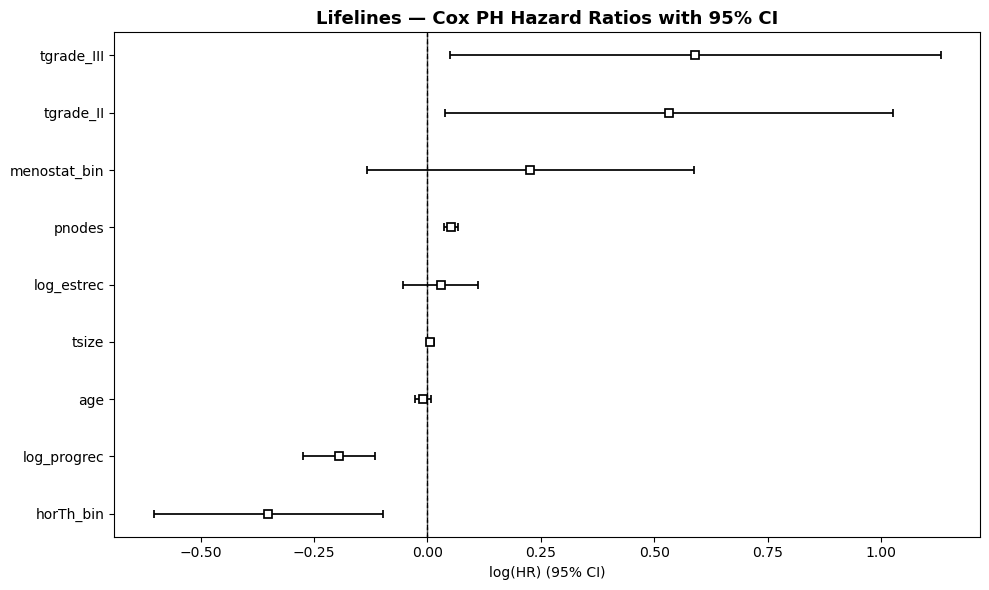

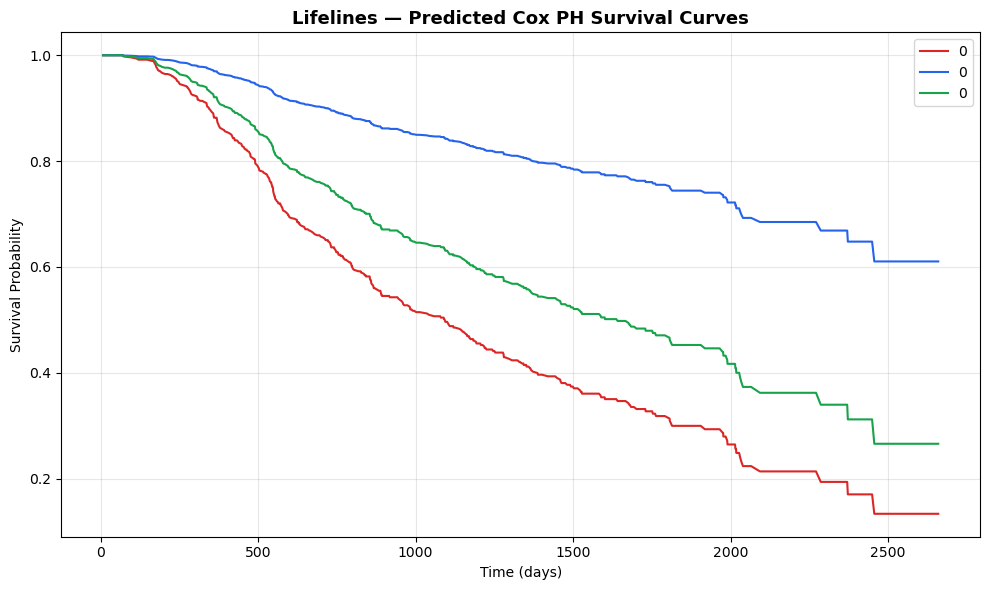

In [49]:
# ═══════════════════════════════════════════════════════════════════════════════
# LIFELINES — COX PROPORTIONAL HAZARDS MODEL
# ═══════════════════════════════════════════════════════════════════════════════

df_cox = df[['horTh_bin', 'age', 'menostat_bin', 'tsize',
             'tgrade_II', 'tgrade_III', 'pnodes',
             'log_progrec', 'log_estrec', 'time', 'cens']].copy()

cph = CoxPHFitter()
cph.fit(df_cox, duration_col='time', event_col='cens')

print("===== LIFELINES COX PH SUMMARY =====")
cph.print_summary()

# ── Forest plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
cph.plot(ax=ax)
ax.set_title('Lifelines — Cox PH Hazard Ratios with 95% CI', fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

# ── Predicted survival: 3 profiles ───────────────────────────────────────────
profile_high = pd.DataFrame({
    'horTh_bin': [0], 'age': [53], 'menostat_bin': [1], 'tsize': [25],
    'tgrade_II': [0], 'tgrade_III': [1], 'pnodes': [10],
    'log_progrec': [np.log1p(df['progrec'].median())],
    'log_estrec':  [np.log1p(df['estrec'].median())]
})
profile_low = pd.DataFrame({
    'horTh_bin': [1], 'age': [53], 'menostat_bin': [1], 'tsize': [25],
    'tgrade_II': [0], 'tgrade_III': [0], 'pnodes': [1],
    'log_progrec': [np.log1p(df['progrec'].median())],
    'log_estrec':  [np.log1p(df['estrec'].median())]
})
profile_med = pd.DataFrame({col: [df[col].median()]
                             for col in df_cox.columns if col not in ['time', 'cens']})

fig, ax = plt.subplots(figsize=(10, 6))
cph.predict_survival_function(profile_high).plot(ax=ax, color=RED,   label='High-risk: Grade III, 10 nodes, no HT')
cph.predict_survival_function(profile_low).plot(ax=ax,  color=BLUE,  label='Low-risk: Grade I, 1 node, HT')
cph.predict_survival_function(profile_med).plot(ax=ax,  color=GREEN, label='Median patient')
ax.set_title('Lifelines — Predicted Cox PH Survival Curves', fontsize=13, fontweight='bold')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Survival Probability')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

===== LIFELINES WEIBULL AFT SUMMARY =====


<lifelines.WeibullAFTFitter: fitted with 686 total observations, 387 right-censored observations>
             duration col = 'time'
                event col = 'cens'
   number of observations = 686
number of events observed = 299
           log-likelihood = -2574.96
         time fit was run = 2026-06-17 22:56:57 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                     
lambda_ age           0.01      1.01      0.01           -0.01            0.02                0.99                1.02
        horTh_bin     0.27      1.31      0.09            0.09            0.45                1.10                1.57
        log_estrec   -0.02      0.98      0.03           -0.08            0.04                0.92                1.04
        log_progrec   0.14      1.15      0.03            0.08            0.20                1.09                1.22
        menostat_bin -0.17      0.84      0.13           -0.42            0.08                0.65                1.09
        pnodes       -0.04      0.96      0.01           -0.05           -0.03                0.95                0.97
        tgrade_II    -0.39      0.67      0.18           -0.75           -0.04                0.47                0.96
        tgrade_III   -0.44      0.64      0.20           -0.83           -0.06                0.44                0.94
        tsize        -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
        Intercept     7.64   2079.98      0.35            6.95            8.33             1044.38             4142.46
rho_    Intercept     0.34      1.41      0.05            0.25            0.44                1.28                1.55

                      cmp to     z      p  -log2(p)
param   covariate                                  
lambda_ age             0.00  1.04   0.30      1.75
        horTh_bin       0.00  2.95 <0.005      8.30
        log_estrec      0.00 -0.77   0.44      1.19
        log_progrec     0.00  4.85 <0.005     19.60
        menostat_bin    0.00 -1.31   0.19      2.40
        pnodes          0.00 -7.17 <0.005     40.33
        tgrade_II       0.00 -2.19   0.03      5.12
        tgrade_III      0.00 -2.25   0.02      5.36
        tsize           0.00 -1.62   0.10      3.26
        Intercept       0.00 21.74 <0.005    345.56
rho_    Intercept       0.00  7.00 <0.005     38.53
---
Concordance = 0.70
AIC = 5171.92
log-likelihood ratio test = 124.64 on 9 df
-log2(p) of ll-ratio test = 72.50

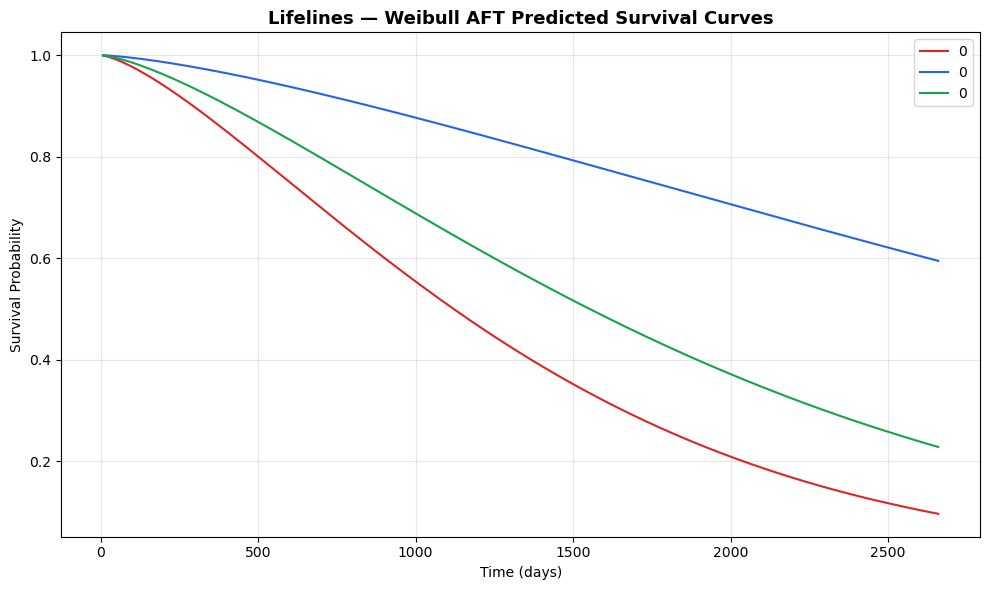

In [50]:
# ═══════════════════════════════════════════════════════════════════════════════
# LIFELINES — WEIBULL AFT MODEL
# ═══════════════════════════════════════════════════════════════════════════════

waf = WeibullAFTFitter()
waf.fit(df_cox, duration_col='time', event_col='cens')

print("===== LIFELINES WEIBULL AFT SUMMARY =====")
waf.print_summary()

fig, ax = plt.subplots(figsize=(10, 6))
waf.predict_survival_function(profile_high).plot(ax=ax, color=RED,   label='High-risk: Grade III, 10 nodes, no HT')
waf.predict_survival_function(profile_low).plot(ax=ax,  color=BLUE,  label='Low-risk: Grade I, 1 node, HT')
waf.predict_survival_function(profile_med).plot(ax=ax,  color=GREEN, label='Median patient')
ax.set_title('Lifelines — Weibull AFT Predicted Survival Curves', fontsize=13, fontweight='bold')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Survival Probability')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Random Survival Forest      — C-index: 0.6731
Gradient Boosting Survival  — C-index: 0.6416
From-scratch Cox PH         — C-index: 0.6960


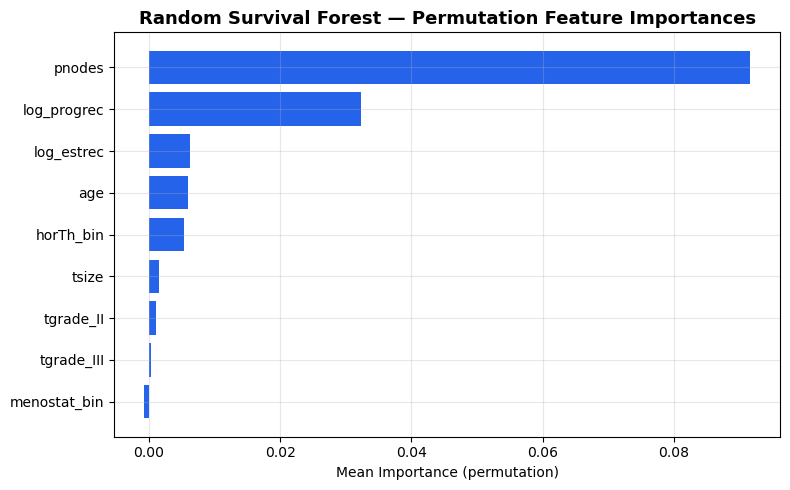

In [51]:
# ═══════════════════════════════════════════════════════════════════════════════
# SCIKIT-SURVIVAL — RANDOM SURVIVAL FOREST & GRADIENT BOOSTING
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# ── Prepare structured array required by scikit-survival ─────────────────────
feature_cols = ['horTh_bin', 'age', 'menostat_bin', 'tsize',
                'tgrade_II', 'tgrade_III', 'pnodes', 'log_progrec', 'log_estrec']

X_sk = df[feature_cols].values.astype(float)
y_sk = np.array([(bool(e), t) for e, t in zip(E, T)],
                dtype=[('cens', bool), ('time', float)])

X_train, X_test, y_train, y_test = train_test_split(
    X_sk, y_sk, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── Random Survival Forest ────────────────────────────────────────────────────
rsf = RandomSurvivalForest(n_estimators=100, min_samples_split=10,
                           min_samples_leaf=15, random_state=42, n_jobs=-1)
rsf.fit(X_train_sc, y_train)
rsf_ci = rsf.score(X_test_sc, y_test)
print(f"Random Survival Forest      — C-index: {rsf_ci:.4f}")

# ── Gradient Boosting Survival ────────────────────────────────────────────────
gbm = GradientBoostingSurvivalAnalysis(n_estimators=100, learning_rate=0.05,
                                        max_depth=3, random_state=42)
gbm.fit(X_train_sc, y_train)
gbm_ci = gbm.score(X_test_sc, y_test)
print(f"Gradient Boosting Survival  — C-index: {gbm_ci:.4f}")
print(f"From-scratch Cox PH         — C-index: 0.6960")

# ── Permutation feature importance from RSF ───────────────────────────────────
perm = permutation_importance(rsf, X_test_sc, y_test,
                               n_repeats=10, random_state=42, n_jobs=-1)

feat_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': perm.importances_mean
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(feat_df['Feature'], feat_df['Importance'], color=BLUE)
ax.set_title('Random Survival Forest — Permutation Feature Importances',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Importance (permutation)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()